In [2]:
import torch
import numpy

In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
print("Current GPU:", torch.cuda.current_device())
print("GPU Name:", torch.cuda.get_device_name(torch.cuda.current_device()))

CUDA available: True
Number of GPUs: 1
Current GPU: 0
GPU Name: NVIDIA GeForce RTX 3070 Laptop GPU


In [4]:
scalar = torch.tensor(7)
scalar

tensor(7)

In [5]:
scalar.item()

7

In [6]:
vector = torch.tensor([7,7])
vector
vector.ndim

1

In [7]:
matrix = torch.tensor([[1, 0],
                       [0, 1]])
matrix.ndim

2

In [8]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.7.1+cu128'

In [9]:
weight = 0.7
bias = 0.3

start  = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight*X+bias

X[:10], y[:10] # up until 0.980 for X (end exclusive)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [10]:
#create training data

train_split = int(0.8*len(X)) #use 80% of data
X_train = X[:train_split]
y_train = y[:train_split]
X_test=X[train_split:]
y_test= y[train_split:]

len(X_train), len(X_test) #40 for training, 10 for testing

(40, 10)

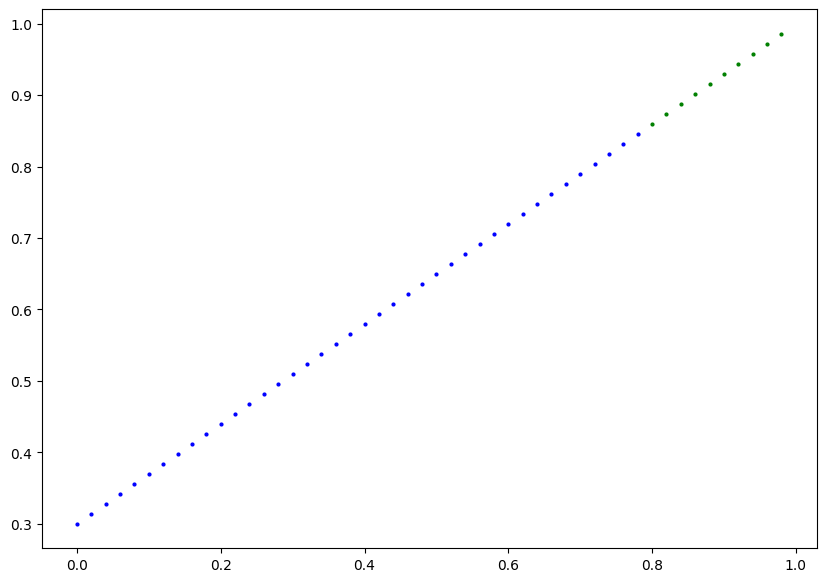

In [11]:
def plot_data(train_data=X_train,
              train_label=y_train,
              test_data=X_test,
              test_label=y_test,
              predictions=None):
    plt.figure(figsize=(10,7))

    #blue training data
    plt.scatter(train_data, train_label, c="b", s=4, label="training")

    #green test data
    plt.scatter(test_data, test_label, c="g", s=4, label="test")


    #predictions in red
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="predictions")





plot_data()

In [12]:
class LinearRegressionModel(nn.Module): #nn.Modules contains all neural network stuff
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
                                    #random weight first before training
                                                                    #update w grad descent
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    #forward is required by nn.Module class
    def forward(self, X:torch.Tensor) -> torch.Tensor:#x is input
        return self.weights*X+self.bias #how we compute the output given input


In [13]:
torch.manual_seed(42) #instead of random initial state we have a fixed one

model = LinearRegressionModel()
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [15]:
#making predictions
with torch.inference_mode():
    y_preds=model(X_test)
    #could be with torch.no_grad in old code

#using the inference mode makes forward pass (calculating actual predictions) faster

#ass predictions before learning
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

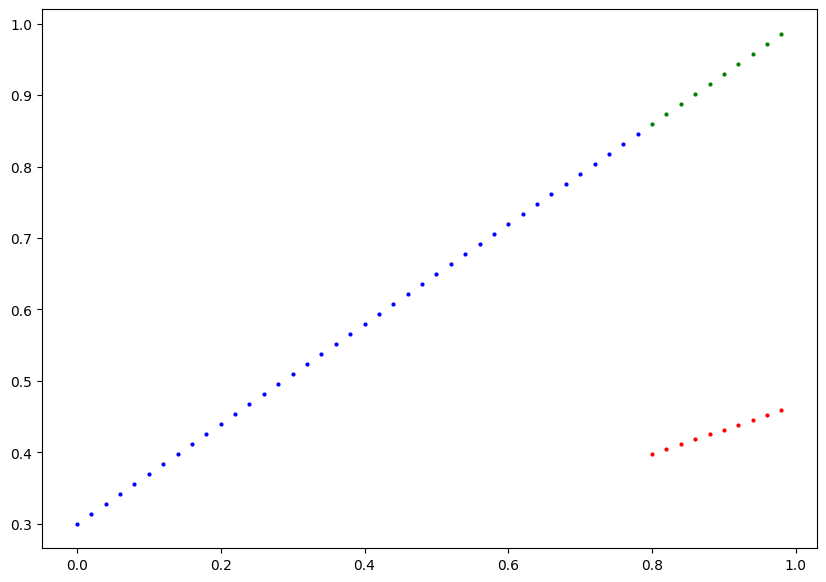

In [16]:
plot_data(predictions=y_preds)

In [17]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)
                            #params=prameters to optimise. lr=learningrate


In [18]:
#training loop:

epochs = 150

for epoch in range(epochs):

    #put in training mode
    model.train()
    #1 (forward pass): calculate current predictions
    y_pred = model(X_train)

    #2: calculate loss
    loss = loss_fn(y_pred, y_train)

    #3: reset gradient
    optimizer.zero_grad()

    #4: backpropagation on the loss
    loss.backward()

    #step optimiser
    optimizer.step()

    #test model

    #put model in evaluation mode
    model.eval()

    with torch.inference_mode():
        #1 forward pass on test data
        test_pred = model(X_test)

        #calculate loss on test
        test_loss = loss_fn(test_pred, y_test.type(torch.float)) #match the prediction datatype

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 
Epoch: 100 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262 
Epoch: 110 | MAE Train Loss: 0.021020207554101944 | MAE

In [19]:
print(model.state_dict())

OrderedDict([('weights', tensor([0.6638])), ('bias', tensor([0.3153]))])


In [28]:
# practice

weight = -3.14
bias = 0.12

X = torch.arange(-1, 1, 0.01) #is unsqueeze necessary? -> if you want to access it like X[0][0] yes.
y = weight * X + bias

In [29]:
y

tensor([ 3.2600,  3.2286,  3.1972,  3.1658,  3.1344,  3.1030,  3.0716,  3.0402,
         3.0088,  2.9774,  2.9460,  2.9146,  2.8832,  2.8518,  2.8204,  2.7890,
         2.7576,  2.7262,  2.6948,  2.6634,  2.6320,  2.6006,  2.5692,  2.5378,
         2.5064,  2.4750,  2.4436,  2.4122,  2.3808,  2.3494,  2.3180,  2.2866,
         2.2552,  2.2238,  2.1924,  2.1610,  2.1296,  2.0982,  2.0668,  2.0354,
         2.0040,  1.9726,  1.9412,  1.9098,  1.8784,  1.8470,  1.8156,  1.7842,
         1.7528,  1.7214,  1.6900,  1.6586,  1.6272,  1.5958,  1.5644,  1.5330,
         1.5016,  1.4702,  1.4388,  1.4074,  1.3760,  1.3446,  1.3132,  1.2818,
         1.2504,  1.2190,  1.1876,  1.1562,  1.1248,  1.0934,  1.0620,  1.0306,
         0.9992,  0.9678,  0.9364,  0.9050,  0.8736,  0.8422,  0.8108,  0.7794,
         0.7480,  0.7166,  0.6852,  0.6538,  0.6224,  0.5910,  0.5596,  0.5282,
         0.4968,  0.4654,  0.4340,  0.4026,  0.3712,  0.3398,  0.3084,  0.2770,
         0.2456,  0.2142,  0.1828,  0.15

In [30]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split]


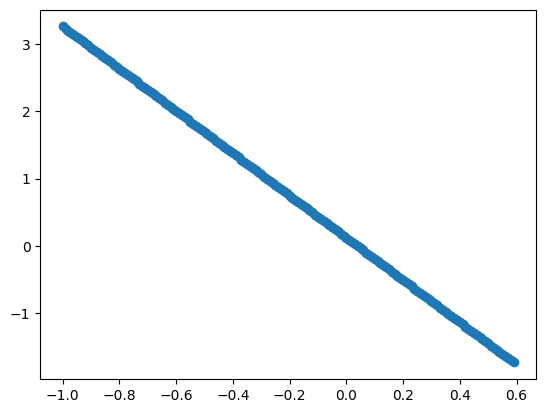

In [31]:
plt.scatter(X_train, y_train)

In [ ]:
class practiceModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(toch.randn(1, dtype=torch.float), requires_grad=True)